# BTC Perpetual — High-Frequency Mean Reversion

Estimating the Ornstein-Uhlenbeck mean-reversion speed on second-scale BTCUSDT
perpetual data, and deciding whether the implied half-life clears the fee tier.

**Model.** Deviation from a local mean follows

$$dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t$$

Discretised at step $\Delta$ this is an AR(1) with slope $b = e^{-\theta\Delta}$,
so $\theta = -\ln b / \Delta$ and the half-life is $\ln 2 / \theta$.

**The question the notebook answers.** Break-even entry deviation under a maker
fee $f$ and spread $s$ is $d^* = 2(2f + s)$. Given the empirical frequency with
which BTC crosses $d^*$, is the resulting trade count enough to carry a Sharpe?

Run with `SYNTHETIC = True` first: it generates a series with a *known*
half-life so you can confirm the estimators recover it before trusting them on
real data.

In [1]:
import io
import math
import zipfile
from dataclasses import dataclass
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

# --- configuration --------------------------------------------------------
SYNTHETIC = True          # start here; flip to False once the self-test passes
SYMBOL = "BTCUSDT"
DATE = "2026-07-01"       # YYYY-MM-DD
BAR_SECONDS = 1
MAKER_FEE_BP = 2.0        # Binance USD-M base tier, per side
CACHE_DIR = Path("./data")

BASE_URL = "https://data.binance.vision/data/futures/um/daily/aggTrades"
AGGTRADE_COLUMNS = [
    "agg_trade_id", "price", "quantity", "first_trade_id",
    "last_trade_id", "transact_time", "is_buyer_maker",
]

## 1. Data

`data.binance.vision` serves daily aggTrade archives for every USD-M perpetual,
free and without an API key, back to 2019. One BTCUSDT day is roughly 3-5M rows
and unzips to a few hundred MB, so the loader caches to parquet.

In [2]:
def download_agg_trades(symbol: str, date: str, cache_dir: Path = CACHE_DIR) -> pd.DataFrame:
    """Fetch one day of aggregated trades, caching the parsed result as parquet."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{symbol}_{date}_aggtrades.parquet"

    if cache_path.exists():
        print(f"[cache] loading {cache_path}")
        return pd.read_parquet(cache_path)

    url = f"{BASE_URL}/{symbol}/{symbol}-aggTrades-{date}.zip"
    print(f"[download] {url}")
    with urlopen(url) as response:
        payload = response.read()

    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        inner_name = archive.namelist()[0]
        with archive.open(inner_name) as handle:
            head = handle.read(200).decode("utf-8", errors="ignore")
            handle.seek(0)
            # Binance added a header row to these archives at some point.
            has_header = "agg_trade_id" in head or "transact_time" in head
            frame = pd.read_csv(
                handle,
                header=0 if has_header else None,
                names=None if has_header else AGGTRADE_COLUMNS,
            )

    frame.columns = [c.strip() for c in frame.columns]
    frame = frame.rename(columns={
        "a": "agg_trade_id", "p": "price", "q": "quantity",
        "f": "first_trade_id", "l": "last_trade_id",
        "T": "transact_time", "m": "is_buyer_maker",
    })

    frame = frame[["transact_time", "price", "quantity", "is_buyer_maker"]].copy()
    frame["price"] = frame["price"].astype(float)
    frame["quantity"] = frame["quantity"].astype(float)

    # Timestamps moved from milliseconds to microseconds in the 2025 files.
    unit = "us" if frame["transact_time"].iloc[0] > 1e15 else "ms"
    frame["timestamp"] = pd.to_datetime(frame["transact_time"], unit=unit, utc=True)
    frame = frame.drop(columns=["transact_time"]).set_index("timestamp").sort_index()

    frame.to_parquet(cache_path)
    print(f"[cache] wrote {cache_path} ({len(frame):,} trades)")
    return frame

In [3]:
def build_bars(trades: pd.DataFrame, bar_seconds: int = 1) -> pd.DataFrame:
    """
    Collapse the trade tape into fixed-interval bars.

    Empty intervals are forward-filled on price rather than dropped. Dropping
    them would compress the effective time step and bias every theta estimate
    downstream -- the single most common error in this kind of study.
    """
    rule = f"{bar_seconds}s"
    notional = trades["price"] * trades["quantity"]

    bars = pd.DataFrame({
        "last": trades["price"].resample(rule).last(),
        "quantity": trades["quantity"].resample(rule).sum(),
        "trade_count": trades["price"].resample(rule).count(),
        "notional": notional.resample(rule).sum(),
    })
    bars["vwap"] = np.where(bars["quantity"] > 0, bars["notional"] / bars["quantity"], np.nan)
    bars["vwap"] = bars["vwap"].ffill()
    bars["last"] = bars["last"].ffill()
    bars["quantity"] = bars["quantity"].fillna(0.0)
    bars["trade_count"] = bars["trade_count"].fillna(0).astype(int)

    return bars.dropna(subset=["last"])

In [4]:
def synthetic_bars(n: int = 40_000, half_life: float = 45.0, seed: int = 7) -> pd.DataFrame:
    """
    Ground-truth series: a random walk plus a mean-reverting component of known
    half-life, plus a one-tick bid-ask bounce. Used to validate the estimators.
    """
    rng = np.random.default_rng(seed)
    theta = math.log(2.0) / half_life
    beta = math.exp(-theta)

    sigma_innovation = 0.8e-4               # roughly 0.8 bp per second
    deviation = np.zeros(n)
    for t in range(1, n):
        deviation[t] = beta * deviation[t - 1] + sigma_innovation * rng.standard_normal()

    drift = np.cumsum(rng.standard_normal(n)) * 0.3e-4
    log_price = math.log(100_000.0) + drift + deviation

    tick = 0.10 / 100_000.0                 # 0.1 USDT tick on a 100k price
    bounce = rng.choice([-0.5, 0.5], size=n) * tick
    prices = np.exp(log_price + bounce)

    index = pd.date_range("2026-07-01", periods=n, freq="1s", tz="UTC")
    return pd.DataFrame({
        "last": prices,
        "quantity": rng.gamma(2.0, 0.5, size=n),
        "trade_count": rng.poisson(12, size=n),
        "notional": 0.0,
        "vwap": prices,
    }, index=index)

In [5]:
if SYNTHETIC:
    TRUE_HALF_LIFE = 45.0
    bars = synthetic_bars(half_life=TRUE_HALF_LIFE)
    print(f"SYNTHETIC MODE -- true half-life = {TRUE_HALF_LIFE} s")
else:
    TRUE_HALF_LIFE = None
    trades = download_agg_trades(SYMBOL, DATE)
    bars = build_bars(trades, BAR_SECONDS)

log_price = np.log(bars["last"].to_numpy())

print(f"bars          : {len(bars):,} at {BAR_SECONDS}s "
      f"({len(bars) * BAR_SECONDS / 3600:.1f} hours)")
print(f"empty bars    : {(bars['trade_count'] == 0).mean() * 100:.2f}%")
print(f"price range   : {bars['last'].min():,.1f} - {bars['last'].max():,.1f}")
bars.head()

SYNTHETIC MODE -- true half-life = 45.0 s
bars          : 40,000 at 1s (11.1 hours)
empty bars    : 0.00%
price range   : 99,654.9 - 101,019.6


,last,quantity,trade_count,notional,vwap
2026-07-01 00:00:00+00:00,99998.586570,0.981392,13,0.0,99998.586570
2026-07-01 00:00:01+00:00,99998.571467,0.559039,8,0.0,99998.571467
2026-07-01 00:00:02+00:00,100001.788633,0.581390,11,0.0,100001.788633
2026-07-01 00:00:03+00:00,99996.960525,0.642131,12,0.0,99996.960525
2026-07-01 00:00:04+00:00,99985.321021,0.667809,14,0.0,99985.321021


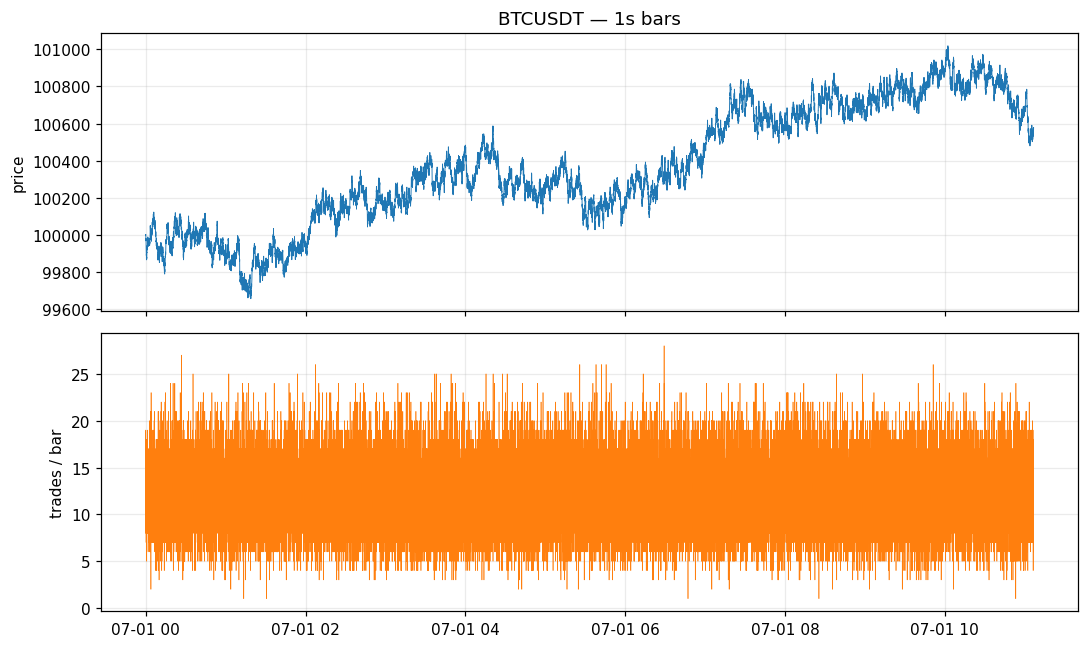

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(bars.index, bars["last"], lw=0.6)
axes[0].set_ylabel("price")
axes[0].set_title(f"{SYMBOL} — {BAR_SECONDS}s bars")
axes[1].plot(bars.index, bars["trade_count"], lw=0.4, color="tab:orange")
axes[1].set_ylabel("trades / bar")
plt.tight_layout()
plt.show()

## 2. Ornstein-Uhlenbeck estimation

The raw log price is not stationary, so $\theta$ is estimated on the deviation
from a rolling mean. **The choice of window is not innocuous** — it defines what
counts as "the mean", and therefore what counts as a deviation. Sweep it rather
than picking one.

In [7]:
@dataclass
class OUFit:
    theta: float          # mean-reversion speed, per second
    mu: float             # long-run level
    sigma: float          # diffusion coefficient, per sqrt(second)
    half_life: float      # seconds
    ar1_beta: float
    r_squared: float
    n_obs: int


def fit_ou(series: np.ndarray, dt: float = 1.0) -> OUFit:
    """
    Exact-discretisation OLS on the AR(1) form. For a Gaussian OU process this
    is the conditional MLE, so a numerical optimiser adds nothing.
    """
    x = np.asarray(series, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 100:
        raise ValueError("need at least 100 observations")

    x_lag, x_now = x[:-1], x[1:]
    design = np.column_stack([np.ones_like(x_lag), x_lag])
    coefficients, *_ = np.linalg.lstsq(design, x_now, rcond=None)
    intercept, beta = coefficients

    residuals = x_now - design @ coefficients
    residual_variance = residuals.var(ddof=2)
    r_squared = 1.0 - residual_variance / x_now.var(ddof=1)

    if not 0.0 < beta < 1.0:
        # Non-stationary or oscillating: theta is not identified.
        return OUFit(float("nan"), float(x.mean()),
                     math.sqrt(residual_variance / dt), float("nan"),
                     beta, r_squared, x.size)

    theta = -math.log(beta) / dt
    mu = intercept / (1.0 - beta)
    sigma = math.sqrt(residual_variance * 2.0 * theta / (1.0 - beta**2))
    half_life = math.log(2.0) / theta

    return OUFit(theta, mu, sigma, half_life, beta, r_squared, x.size)

In [8]:
WINDOWS = [10, 20, 30, 60, 120, 300, 600, 1200]

log_series = pd.Series(log_price)
records = []
for window in WINDOWS:
    if window * 5 > len(log_series):
        continue
    centre = log_series.rolling(window, min_periods=window).mean()
    deviation = (log_series - centre).dropna().to_numpy()
    fit = fit_ou(deviation, dt=float(BAR_SECONDS))
    records.append({
        "window_s": window * BAR_SECONDS,
        "ar1_beta": fit.ar1_beta,
        "theta": fit.theta,
        "half_life_s": fit.half_life,
        "r_squared": fit.r_squared,
        "n_obs": fit.n_obs,
    })

ou_table = pd.DataFrame(records).set_index("window_s")
ou_table.round(6)

,ar1_beta,theta,half_life_s,r_squared,n_obs
window_s,,,,,
10,0.837328,0.177539,3.904195,0.701083,39991
20,0.917853,0.085719,8.086315,0.842516,39981
30,0.943649,0.058001,11.950642,0.890576,39971
60,0.968973,0.031518,21.991775,0.938887,39941
120,0.980818,0.019368,35.788513,0.962007,39881
300,0.988149,0.011922,58.140385,0.976487,39701
600,0.991168,0.008871,78.137931,0.982418,39401
1200,0.993695,0.006325,109.585964,0.987396,38801


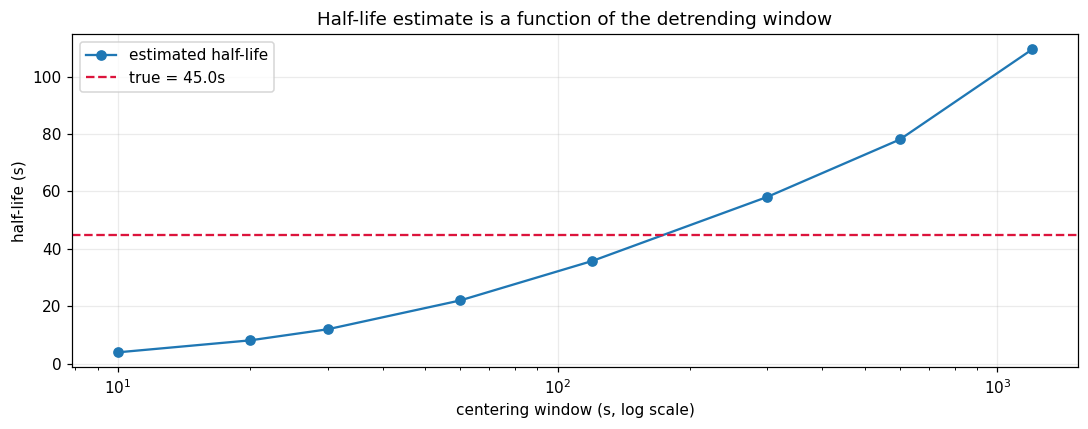

If this curve has no flat region, theta is not identified by the data —
it is being set by your window choice. That is the result, not a bug.


In [9]:
fig, ax = plt.subplots()
ax.plot(ou_table.index, ou_table["half_life_s"], "o-", label="estimated half-life")
if TRUE_HALF_LIFE is not None:
    ax.axhline(TRUE_HALF_LIFE, color="crimson", ls="--", label=f"true = {TRUE_HALF_LIFE}s")
ax.set_xscale("log")
ax.set_xlabel("centering window (s, log scale)")
ax.set_ylabel("half-life (s)")
ax.set_title("Half-life estimate is a function of the detrending window")
ax.legend()
plt.tight_layout()
plt.show()

print("If this curve has no flat region, theta is not identified by the data —")
print("it is being set by your window choice. That is the result, not a bug.")

## 3. Variance ratio (Lo & MacKinlay, 1988)

A model-free cross-check. $VR(q) < 1$ means negative serial correlation over
$q$-step horizons, i.e. mean reversion; $VR(q) > 1$ means trending. The
heteroskedasticity-robust $z$ handles the volatility clustering that makes the
homoskedastic version useless on crypto.

In [10]:
def variance_ratio(log_prices: np.ndarray, q: int) -> tuple[float, float]:
    """Returns (VR, heteroskedasticity-robust z-statistic)."""
    p = np.asarray(log_prices, dtype=float)
    p = p[np.isfinite(p)]
    n = p.size - 1
    if n < 10 * q:
        raise ValueError(f"series too short for q={q}")

    diffs = np.diff(p)
    mu_hat = diffs.mean()

    var_1 = np.sum((diffs - mu_hat) ** 2) / (n - 1)
    q_diffs = p[q:] - p[:-q]
    m = q * (n - q + 1) * (1.0 - q / n)
    var_q = np.sum((q_diffs - q * mu_hat) ** 2) / m
    vr = var_q / var_1

    centered_sq = (diffs - mu_hat) ** 2
    denominator = centered_sq.sum() ** 2
    theta_star = 0.0
    for j in range(1, q):
        delta_j = np.sum(centered_sq[j:] * centered_sq[:-j]) / denominator
        theta_star += (2.0 * (q - j) / q) ** 2 * delta_j

    z_stat = (vr - 1.0) / math.sqrt(theta_star) if theta_star > 0 else float("nan")
    return vr, z_stat

In [11]:
Q_VALUES = [2, 3, 5, 10, 15, 30, 60, 120, 300, 600]

vr_records = []
for q in Q_VALUES:
    try:
        vr, z = variance_ratio(log_price, q)
    except ValueError:
        continue
    vr_records.append({"q": q, "horizon_s": q * BAR_SECONDS, "VR": vr, "z": z})

vr_table = pd.DataFrame(vr_records).set_index("q")
vr_table.round(4)

,horizon_s,VR,z
q,,,
2,2,0.9924,-1.5269
3,3,0.9892,-1.4483
5,5,0.9850,-1.3710
10,10,0.9619,-2.2518
15,15,0.9389,-2.8686
30,30,0.8726,-4.1229
60,60,0.7581,-5.4677
120,120,0.5661,-6.8966
300,300,0.3516,-6.5001


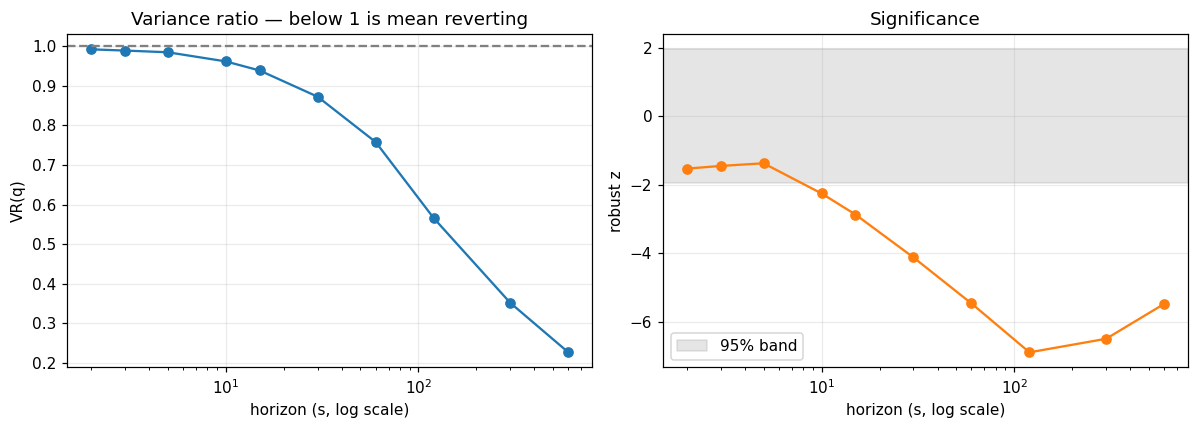

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(vr_table["horizon_s"], vr_table["VR"], "o-")
axes[0].axhline(1.0, color="grey", ls="--")
axes[0].set_xscale("log")
axes[0].set_xlabel("horizon (s, log scale)")
axes[0].set_ylabel("VR(q)")
axes[0].set_title("Variance ratio — below 1 is mean reverting")

axes[1].plot(vr_table["horizon_s"], vr_table["z"], "o-", color="tab:orange")
axes[1].axhspan(-1.96, 1.96, color="grey", alpha=0.2, label="95% band")
axes[1].set_xscale("log")
axes[1].set_xlabel("horizon (s, log scale)")
axes[1].set_ylabel("robust z")
axes[1].set_title("Significance")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Roll (1984) implied spread — and why it will mislead you here

Under pure bid-ask bounce, $\operatorname{Cov}(\Delta P_t, \Delta P_{t-1}) = -s^2/4$.
But genuine mean reversion *also* produces negative autocovariance, so this
estimator conflates the two and overstates the spread whenever real reversion is
present. Verify the size of the bias in synthetic mode before reading anything
into the real-data number.

Separating bounce from signal properly needs quote data (`bookTicker`), not the
trade tape.

In [13]:
def roll_effective_spread(prices: np.ndarray) -> float:
    """Roll (1984) implied effective spread, in bp of the mean price."""
    p = np.asarray(prices, dtype=float)
    changes = np.diff(p)
    covariance = np.cov(changes[1:], changes[:-1])[0, 1]
    if covariance >= 0:
        return float("nan")     # bounce model does not bind
    return 2.0 * math.sqrt(-covariance) / p.mean() * 1e4


roll_bp = roll_effective_spread(bars["last"].to_numpy())
print(f"Roll implied effective spread: {roll_bp:.4f} bp")
if SYNTHETIC:
    injected_bp = 0.10 / 100_000.0 * 1e4
    print(f"actually injected            : {injected_bp:.4f} bp")
    print(f"overstatement factor         : {roll_bp / injected_bp:.1f}x")

Roll implied effective spread: 0.1491 bp
actually injected            : 0.0100 bp
overstatement factor         : 14.9x


## 5. Economics

A deviation $d$ is worth trading only if the expected capture (roughly $d/2$
when entering at $d$ and exiting near the mean) clears the round trip:

$$\frac{d}{2} > 2f + s \quad\Longrightarrow\quad d^* = 2(2f + s)$$

At the Binance base tier $f = 2$ bp, so $d^* \approx 8$ bp — which the price
needs roughly $(d^*/\sigma_{1s})^2$ seconds of diffusion to reach.

In [14]:
spread_bp = 0.0 if math.isnan(roll_bp) else roll_bp
cost_bp = 2.0 * MAKER_FEE_BP + spread_bp
breakeven_bp = 2.0 * cost_bp

sigma_per_second_bp = np.diff(log_price).std(ddof=1) * 1e4 / math.sqrt(BAR_SECONDS)
seconds_to_breakeven = (breakeven_bp / sigma_per_second_bp) ** 2

print(f"maker fee per side   : {MAKER_FEE_BP:.4f} bp")
print(f"effective spread     : {spread_bp:.4f} bp")
print(f"round-trip cost      : {cost_bp:.4f} bp")
print(f"break-even deviation : {breakeven_bp:.4f} bp")
print(f"realised vol         : {sigma_per_second_bp:.4f} bp / sqrt(s)")
print(f"diffusion time to it : {seconds_to_breakeven:.1f} s")

maker fee per side   : 2.0000 bp
effective spread     : 0.1491 bp
round-trip cost      : 4.1491 bp
break-even deviation : 8.2983 bp
realised vol         : 0.8538 bp / sqrt(s)
diffusion time to it : 94.5 s


In [15]:
# Entry threshold sweep. At exactly break-even the net edge is zero by
# construction, so a single point says nothing -- the trade-off between edge per
# trade and trade count only appears across a range.
SWEEP_WINDOW = 120      # centering window used to define the deviation

centre = log_series.rolling(SWEEP_WINDOW, min_periods=SWEEP_WINDOW).mean()
deviation_bp = ((log_series - centre).dropna() * 1e4).to_numpy()
seconds_observed = len(deviation_bp) * BAR_SECONDS

sweep = []
for multiple in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 4.0]:
    entry_bp = breakeven_bp * multiple
    edge_bp = entry_bp / 2.0 - cost_bp

    outside = np.abs(deviation_bp) > entry_bp
    crossings = int(np.sum(outside[1:] & ~outside[:-1]))
    trades_per_day = crossings / seconds_observed * 86400.0

    holding_seconds = max((entry_bp / sigma_per_second_bp) ** 2, 1.0)
    trade_vol_bp = sigma_per_second_bp * math.sqrt(holding_seconds)
    sharpe = ((edge_bp / trade_vol_bp) * math.sqrt(trades_per_day * 365)
              if trades_per_day > 0 and edge_bp > 0 else 0.0)

    sweep.append({
        "multiple": multiple,
        "entry_bp": entry_bp,
        "edge_bp": edge_bp,
        "crossings": crossings,
        "trades_per_day": trades_per_day,
        "holding_s": holding_seconds,
        "sharpe_ceiling": sharpe,
    })

sweep_table = pd.DataFrame(sweep).set_index("multiple")
sweep_table.round(3)

,entry_bp,edge_bp,crossings,trades_per_day,holding_s,sharpe_ceiling
multiple,,,,,,
0.50,4.149,-2.075,1577,3416.484,23.616,0.000
0.75,6.224,-1.037,928,2010.461,53.137,0.000
1.00,8.298,0.000,375,812.417,94.465,0.000
1.25,10.373,1.037,131,283.804,147.602,32.185
1.50,12.447,2.075,46,99.656,212.547,31.787
2.00,16.597,4.149,2,4.333,377.862,9.942
2.50,20.746,6.224,0,0.000,590.409,0.000
3.00,24.895,8.298,0,0.000,850.189,0.000
4.00,33.193,12.447,0,0.000,1511.447,0.000


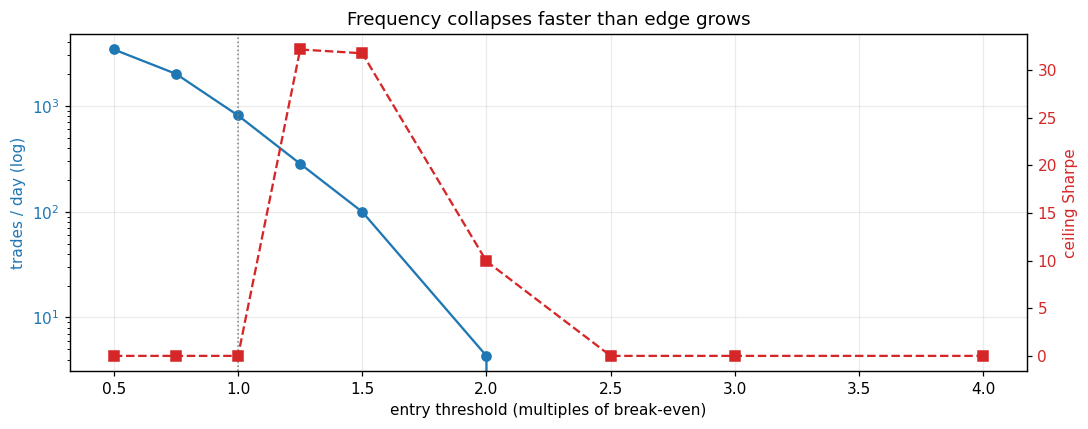

In [16]:
fig, ax1 = plt.subplots()
ax1.plot(sweep_table.index, sweep_table["trades_per_day"], "o-", color="tab:blue")
ax1.set_yscale("log")
ax1.set_xlabel("entry threshold (multiples of break-even)")
ax1.set_ylabel("trades / day (log)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sweep_table.index, sweep_table["sharpe_ceiling"], "s--", color="tab:red")
ax2.set_ylabel("ceiling Sharpe", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.grid(False)

ax1.axvline(1.0, color="grey", ls=":", lw=1)
ax1.set_title("Frequency collapses faster than edge grows")
plt.tight_layout()
plt.show()

## 6. What to read off this

The Sharpe column is a **ceiling**, not a forecast. It assumes every threshold
crossing reverts, no adverse selection, and a 100% maker fill rate — none of
which hold. Treat it as the number the strategy could not possibly beat.

Three things decide whether this continues:

1. **Is there a flat region in the half-life vs window curve?** No flat region
   means $\theta$ is an artefact of the detrending choice and there is nothing
   to trade.
2. **Does $VR(q)$ stay below 1 with $|z| > 2$ out to the break-even horizon?**
   Reversion at 2 seconds is useless if the break-even horizon is 90.
3. **What is `trades_per_day` at multiple = 2.0?** Under a Gaussian this
   collapses to near zero. BTC has fatter tails, so the real number will be
   higher — how much higher is the whole question.

**Next iteration if the numbers survive:** pull `bookTicker` for real quotes
instead of inferring the spread from Roll, add a queue-position model for maker
fill probability, and re-run the sweep at a zero or negative maker fee to see
how far the optimum shifts.